In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d
import copy
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

#%matplotlib widget

### LCDM

In [2]:

# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
k_out = [0.0001, 0.001, 0.01, 0.1]
colors = ['b', 'brown', 'r', 'g', 'c', 'm', 'y', 'k']

gammak = np.pi/2
masses = [1.e-25]
mass_in_Mpc = [m*1.56373846613383*1.e29 for m in masses]

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'tol_perturbations_integration': 1.e-6
}

frac = 1-1.e-6
common_settings  = {
            'h' : h_planck, 
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'svt_coupling' : 'yes',
            'vf_tuning_index' : 3,
            'vector_background_mode': 'bianchi',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl,mPk',
            'k_output_values':str(k_out).strip('[]'),
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_max_h/Mpc' : 10,
            'A_s' : As,
            'n_s' : ns,
            'modes' : 's',
            'gamma_Ak': gammak,
            'recombination' : 'RECFAST'
            }
common_settings.update(precision_settings) 

In [4]:
mass = masses[0]

M = Class()
M.set(common_settings)
M.set({'vf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % mass})
M.compute()

perturbations = copy.deepcopy(M.get_perturbations())
background    = copy.deepcopy(M.get_background())
h             = M.h()

M.struct_cleanup()
M.empty()

In [5]:
h = h_planck
background_z = background['z'] # read redshift
background_a = 1/(1+background_z)
rad_abundance = background['(.)rho_g']/background['(.)rho_crit']
mat_abundance = np.exp(background['Omega_vf'])+background['(.)rho_b']/background['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)(1.)
a_osc = interp1d(background['H [1/Mpc]']/(masses[0] * 1.56 * 1.e29), background_a)(1.)
H_of_a = interp1d(background_a, background['H [1/Mpc]'])

background_H_over_m = background['H [1/Mpc]']/(masses[0] * 1.56 * 1.e29) # read k/aH = k(1+z)/H
a_osc = interp1d(background_H_over_m, background_a)(1.)
H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

kj =  a_osc * np.sqrt(masses[0] * 1.56 * 10**(29) * H_osc) / h
kj0 =  np.sqrt(masses[0] * 1.56 * 10**(29) * background['H [1/Mpc]'][-1])
print('aosc = %s' % a_osc)
print(r'k_j =  %s h/Mpc' % kj)
print(r'k_j =  %s 1/Mpc' % str(kj*h))
print(r'k_j0 = ', kj0)

aosc = 1.1849184184914683e-05
k_j =  0.27638647321272286 h/Mpc
k_j =  0.18484727328466904 1/Mpc
k_j0 =  1.8655207324257717


## $h_+$

### VFDM (coupled evolution)

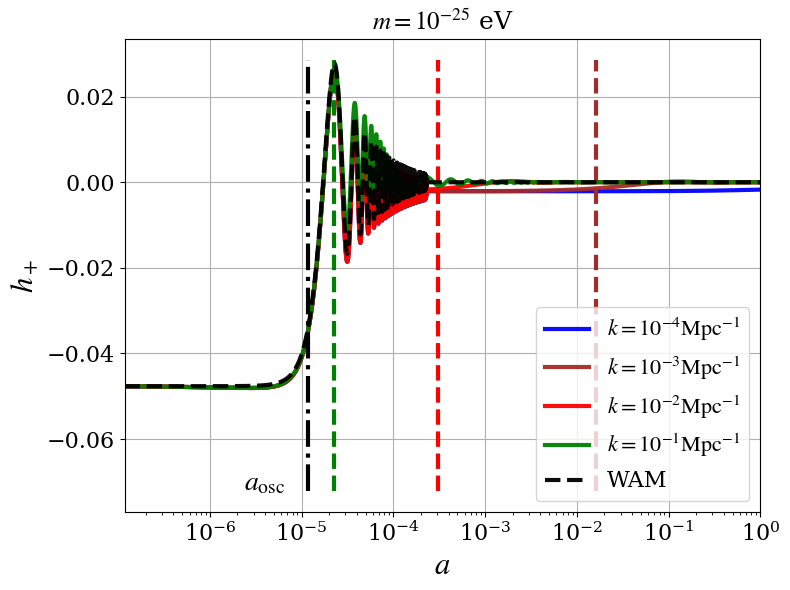

In [6]:
# h_+
m = masses[0]
plt.figure(figsize=(8, 6))
for k in range(len(k_out)):
   one_kpi2 = perturbations['scalar'][k]
   hpi2 = one_kpi2['h_+']
   api2 = one_kpi2['a']
   if k==0:
      ymin = 1.5*min(hpi2)
      ymax = 1.1*max(hpi2)
   background_k_over_aH = k_out[k]/(background['H [1/Mpc]']*background_a)
   try:
      k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
      plt.vlines(x=k_over_aH, ymin=ymin, ymax=ymax, colors=colors[k], linestyles='dashed', lw=3)
   except ValueError:
      pass
   plt.semilogx(api2, hpi2, colors[k], linestyle='solid', label=r'$k = 10^{%s} \rm{Mpc}^{-1}$'%str(int(np.log10(k_out[k]))), lw=3, alpha=0.95)

Omega_A = interp1d(background_a, background['(.)rho_vf']/background['H [1/Mpc]']**2)
rho_A = interp1d(background_a, background['(.)rho_vf'])
a_osc = interp1d(background['H [1/Mpc]']/(m * 1.56 * 1.e29), background_a)(1.)
weinberg = interp1d(background_a, 3./4.*np.sin(gammak)**2 * background['sigma_A [1/Mpc]']*(1+0.*background['sigma_A [1/Mpc]']/(background['H [1/Mpc]']*background_a))/(background['H [1/Mpc]']*background_a))(api2)
plt.vlines(x=a_osc, ymin=ymin, ymax=ymax, color='k',linestyle='dashdot', lw=3)
plt.semilogx(api2, (hpi2[0]-weinberg[0]) + weinberg, 'k', label='WAM', linestyle='dashed', lw=3, alpha=0.95)
plt.xlabel(r'$a$', size=22)
plt.ylabel(r'$h_+$', size=22)
plt.legend(fontsize=16)
plt.xlim(api2[0], 1)
plt.text(0.2*a_osc, ymin, r'$a_{\rm osc}$', fontsize=20)
plt.tick_params(labelsize=16)
plt.title(r'$m = 10^{%s}$ eV'% str(m)[-3:], fontsize=18)
plt.tight_layout()
plt.grid()
plt.savefig('../../Figures/h_+_m=%s_II.pdf'%str(m)[3:])
plt.show() 

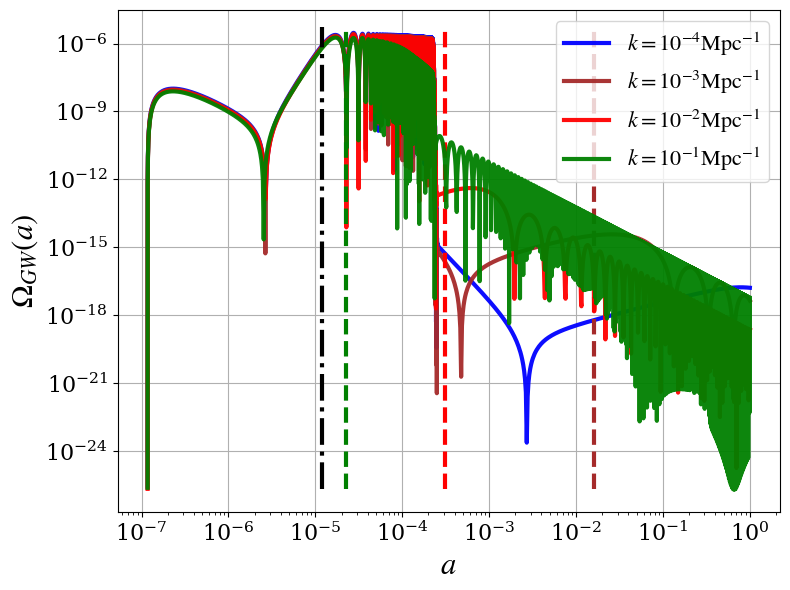

In [7]:
c_light = 3 * 1.e5 # km/s 
H0 = 67/(c_light)
As = 2.092 * 1.e-9
kp = 0.05

plt.figure(figsize=(8, 6))
for i,k in enumerate(k_out):
   one_kpi2 = perturbations['scalar'][i]

   Omega = (2*np.pi)**3 * As * np.pow(k/kp, ns-1)*one_kpi2['d(h_+)']*one_kpi2['d(h_+)']/(48*np.pow(np.pi,3)*H0**2)
   api2 = one_kpi2['a']
   if i==0:
      ymin = 0.8*min(Omega)
      ymax = 1.8*max(Omega)
   
   background_k_over_aH = k/(background['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
   try:
      k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
      plt.vlines(x=k_over_aH, ymin=ymin, ymax=ymax, colors=colors[i], linestyles='dashed', lw=3)
   except ValueError:
      pass
   Omega_A = interp1d(background_a, background['(.)rho_vf']/background['H [1/Mpc]']**2)
   rho_A = interp1d(background_a, background['(.)rho_vf'])

   a_osc = interp1d(background['H [1/Mpc]']/(m * 1.56 * 1.e29), background_a)(1.)
   weinberg = interp1d(background_a, background['sigma_A [1/Mpc]'] * background['proper time [Gyr]']/background_a)(api2)
   plt.xlabel(r'$a$', size=22)
   plt.ylabel(r'$\Omega_{GW}(a)$', size=22)
   plt.loglog(api2, Omega, colors[i], linestyle='solid', label=r'$k = 10^{%s} \rm{Mpc}^{-1}$'%str(int(np.log10(k))), lw=3, alpha=0.95)#label=r'$m = 10^{-%s}$eV' %str(m)[3:]
   
plt.vlines(x=a_osc, ymin=ymin, ymax=ymax, color='k',linestyle='dashdot', lw=3)
plt.legend(fontsize=16)
plt.tick_params(labelsize=16)
plt.grid()
plt.tight_layout()
plt.savefig('../../Figures/Omega_GW_+_m=%s.pdf'%str(m)[3:])
plt.show() 

### Zoom  (works with $m = 10^{-25}$)

/tmp/ipykernel_42545/2046309692.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


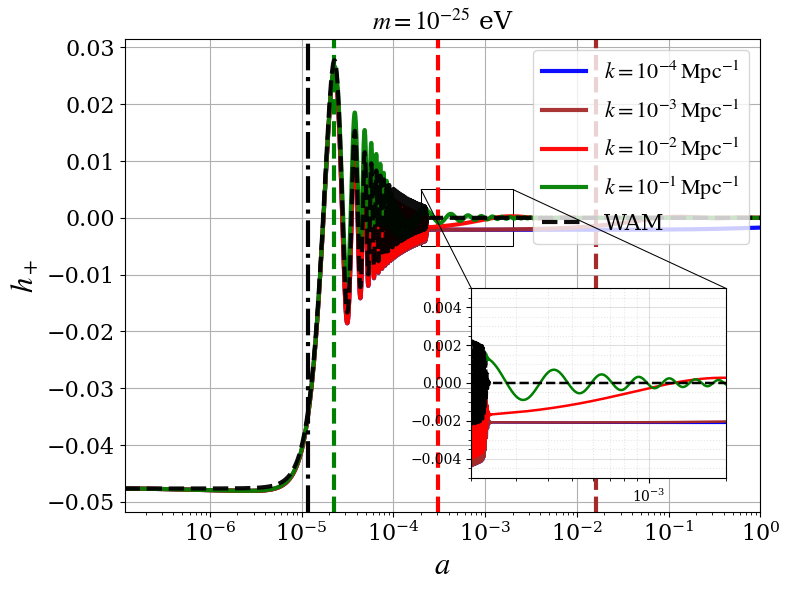

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# Precompute data for all k modes
plot_data = []
for k in range(len(k_out)):
    pert = perturbations['scalar'][k]
    api2, hpi2 = pert['a'], pert['h_+']
    plot_data.append((api2, hpi2))

    if k == 0:
        ymin, ymax = 1.5 * min(hpi2), 1.1 * max(hpi2)

    try:
        k_over_aH = interp1d(k_out[k] / (background['H [1/Mpc]'] * background_a), background_a)(1.)
        ax.axvline(k_over_aH, color=colors[k], ls='dashed', lw=3)
    except ValueError:
        pass

    ax.semilogx(api2, hpi2, color=colors[k], lw=3, alpha=0.95,
                label=r'$k = 10^{%d}\,\rm{Mpc}^{-1}$' % int(np.log10(k_out[k])))

m = masses[0]
a_osc = interp1d(background['H [1/Mpc]'] / (m * 1.56e29), background_a)(1.)
weinberg = interp1d(background_a, 3./4. * np.sin(gammak)**2 * background['sigma_A [1/Mpc]'] / (background['H [1/Mpc]'] * background_a))(api2)

ax.semilogx(api2, hpi2[0] - weinberg[0] + weinberg, 'k--', lw=3, alpha=0.95, label='WAM')
ax.axvline(a_osc, color='k', ls='dashdot', lw=3)

# Inset zoom
axins = inset_axes(ax, width="40%", height="40%", loc='lower right', borderpad=2.5)
axins.set_xlim(2e-4, 2e-3)
axins.set_ylim(-0.005, 0.005)
axins.set_xscale('log')

for k, (a, h) in enumerate(plot_data):
    axins.semilogx(a, h, color=colors[k], lw=1.8)
axins.semilogx(api2, hpi2[0] - weinberg[0] + weinberg, 'k--', lw=1.8)

mark_inset(ax, axins, loc1=1, loc2=2, fc="none", ec="black", lw=0.75)
axins.grid(True, which='major', ls='-', alpha=0.4)
axins.grid(True, which='minor', ls=':', alpha=0.3)
axins.minorticks_on()
axins.tick_params(labelsize=10)

ax.set(xlabel=r'$a$', ylabel=r'$h_+$', xlim=(api2[0], 1))
ax.xaxis.label.set_size(22); ax.yaxis.label.set_size(22)
ax.tick_params(labelsize=16)
ax.legend(fontsize=16, loc='upper right')
ax.set_title(r'$m = 10^{%s}$ eV' % str(m)[-3:], fontsize=18)
ax.grid()
#plt.text(0.2*a_osc, ymin, r'$a_{\rm osc}$', fontsize=20)
plt.tight_layout()
plt.savefig('../../Figures/h_+_m=%s_II.pdf' % str(m)[3:])
plt.show()

## $h_{\times}$

The WAM is a numerical error due to np.cos(np.pi/2) != 0 


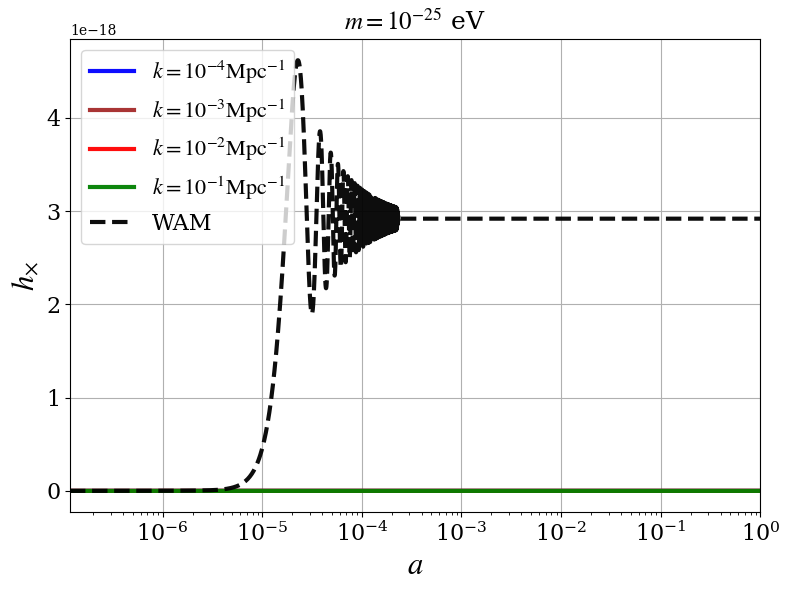

In [9]:
# h_x
m = masses[0]
plt.figure(figsize=(8, 6))
for k in range(len(k_out)):
   one_kpi2 = perturbations['scalar'][k]
   hpi2 = one_kpi2['h_x']
   api2 = one_kpi2['a']
   if k==0:
      ymin = 1.5*min(hpi2)
      ymax = 1.1*max(hpi2)
   background_k_over_aH = k_out[k]/(background['H [1/Mpc]']*background_a)
   try:
      k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
      plt.vlines(x=k_over_aH, ymin=ymin, ymax=ymax, colors=colors[k], linestyles='dashed', lw=3)
   except ValueError:
      pass
   plt.semilogx(api2, hpi2, colors[k], linestyle='solid', label=r'$k = 10^{%s} \rm{Mpc}^{-1}$'%str(int(np.log10(k_out[k]))), lw=3, alpha=0.95)

Omega_A = interp1d(background_a, background['(.)rho_vf']/background['H [1/Mpc]']**2)
rho_A = interp1d(background_a, background['(.)rho_vf'])
a_osc = interp1d(background['H [1/Mpc]']/(m * 1.56 * 1.e29), background_a)(1.)
weinberg_cross = interp1d(background_a, 3./4.*np.sin(gammak)*np.cos(gammak) * background['sigma_A [1/Mpc]']/(background['H [1/Mpc]']*background_a))(api2)
plt.vlines(x=a_osc, ymin=ymin, ymax=ymax, color='k',linestyle='dashdot', lw=3)
plt.semilogx(api2, (hpi2[0]-weinberg_cross[0]) + weinberg_cross, 'k', label='WAM', linestyle='dashed', lw=3, alpha=0.95)
plt.xlabel(r'$a$', size=22)
plt.ylabel(r'$h_{\times}$', size=22)
plt.legend(fontsize=16)
plt.xlim(api2[0], 1)
plt.tick_params(labelsize=16)
plt.title(r'$m = 10^{%s}$ eV'% str(m)[-3:], fontsize=18)
plt.tight_layout()
plt.grid()
plt.savefig('../../Figures/h_x_m=%s_II.pdf'%str(m)[3:])
print('The WAM is a numerical error due to np.cos(np.pi/2) != 0 ')
plt.show() 